# EFGP-SING vs SING-SparseGP on a 2D damped rotation

Both methods should recover the latents and the drift cleanly. We compare
wall time, latent RMSE (Procrustes-aligned to handle the (C, x) basis
non-identifiability), and drift recovery on a grid (in truth basis).

* True drift: `f(x) = A x` with `A = [[-0.6, 1.0], [-1.0, -0.6]]` -> a
  damped 2D rotation, well within both methods' expressive power.
* d=2 latent, T=500, t_max=10, sigma=0.3, 8 noisy linear observations.


In [1]:
import sys
from pathlib import Path
_SING = Path('/Users/colecitrenbaum/Documents/GPs/sing')
if str(_SING) not in sys.path:
    sys.path.insert(0, str(_SING))

import jax
# NOTE: do NOT enable x64; sing.efgp_jax_primitives uses float32 finufft internally.
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import time
import matplotlib.pyplot as plt

from sing.likelihoods import Likelihood
from sing.simulate_data import simulate_sde, simulate_gaussian_obs
from sing.sde import SparseGP
from sing.kernels import RBF
from sing.expectation import GaussHermiteQuadrature
from sing.sing import fit_variational_em
from sing.initialization import initialize_zs
import sing.efgp_em as em
import sing.efgp_jax_primitives as jp
import sing.efgp_jax_drift as jpd

print('jax devices:', jax.devices())


jax devices: [CpuDevice(id=0)]


## 1. Generate data: damped 2D rotation

In [2]:
D = 2
T = 500
t_max = 10.0
sigma_diffusion = 0.3
N_obs = 8

A_true = jnp.array([[-0.6, 1.0],
                    [-1.0, -0.6]])

def drift_jax(x, t):
    return A_true @ x

def drift_np(x_batch):
    return np.asarray(x_batch) @ np.asarray(A_true).T

sigma_fn = lambda x, t: sigma_diffusion * jnp.eye(D)

x0 = jnp.array([2.0, 0.0])
xs = simulate_sde(jr.PRNGKey(7), x0=x0, f=drift_jax,
                  t_max=t_max, n_timesteps=T, sigma=sigma_fn)

rng = np.random.default_rng(0)
C_true = rng.standard_normal((N_obs, D)) * 0.5
out_true = dict(C=jnp.asarray(C_true),
                d=jnp.zeros(N_obs),
                R=jnp.full((N_obs,), 0.05))
ys = simulate_gaussian_obs(jr.PRNGKey(1), xs, out_true)

print(f'xs shape: {xs.shape}, std={float(jnp.std(xs)):.3f}, '
      f'range=({float(xs.min()):.2f}, {float(xs.max()):.2f})')
print(f'ys shape: {ys.shape}, std={float(jnp.std(ys)):.3f}')


/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


xs shape: (500, 2), std=0.564, range=(-1.27, 2.02)
ys shape: (500, 8), std=0.416


## 2. Visualize ground-truth latents and drift

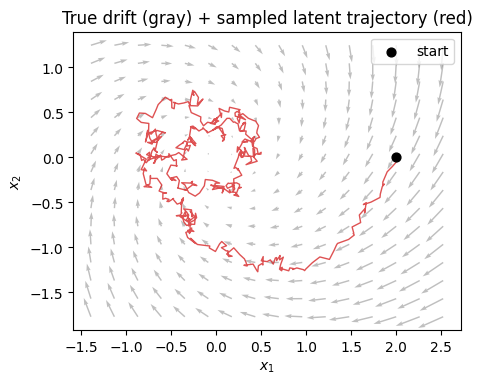

In [3]:
xs_np = np.asarray(xs)
lo = xs_np.min(0) - 0.5; hi = xs_np.max(0) + 0.5
g1 = np.linspace(lo[0], hi[0], 16); g2 = np.linspace(lo[1], hi[1], 16)
G1, G2 = np.meshgrid(g1, g2, indexing='ij')
grid_pts_viz = np.stack([G1.ravel(), G2.ravel()], axis=-1)
F_viz = drift_np(grid_pts_viz)

fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(G1, G2, F_viz[:, 0].reshape(G1.shape), F_viz[:, 1].reshape(G1.shape),
          color='gray', alpha=0.5, scale_units='xy', angles='xy')
ax.plot(xs_np[:, 0], xs_np[:, 1], lw=1.0, color='C3', alpha=0.8)
ax.scatter(xs_np[0, 0], xs_np[0, 1], color='black', s=40, zorder=5, label='start')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('True drift (gray) + sampled latent trajectory (red)')
ax.legend(); ax.set_aspect('equal'); plt.show()


## 3. Shared init (PCA emissions, mu0=0, V0=0.1·I), shared likelihood

In [11]:
class GLik(Likelihood):
    def ell(self, y, mean, var, output_params):
        R = output_params['R']
        return jnp.sum(-0.5 * jnp.log(2 * jnp.pi * R)
                       - 0.5 * ((y - mean) ** 2 + var) / R)

lik = GLik(ys[None], jnp.ones((1, T), dtype=bool))

# PCA-init for emissions
yc = ys - ys.mean(0)
_, _, Vt = jnp.linalg.svd(yc, full_matrices=False)
op_init = dict(C=Vt[:D].T, d=ys.mean(0), R=jnp.full((N_obs,), 0.1))
ip_init = jax.tree_util.tree_map(
    lambda x: x[None],
    dict(mu0=jnp.zeros(D), V0=jnp.eye(D) * 0.1))
t_grid = jnp.linspace(0., t_max, T)

init_lengthscale = 1.5
init_variance = 1.0


# ── Shared EM config (identical for both methods) ────────────────────────────
n_em = 50
n_estep = 5
n_mstep = 5          # inner M-step Adam steps
mstep_lr = 0.01       # Adam lr for kernel hypers (same for both)
rho_sched_sp = jnp.logspace(-2, -1, n_em)   # 0.01→0.1 for SparseGP (GH quad: accurate, small rho ok)
rho_sched_ef = jnp.linspace(0.1, 0.3, n_em)    # 0.1→0.3 for EFGP (MC-based; needs larger rho to overcome noise)
print(f'n_em={n_em}, n_estep={n_estep}, n_mstep={n_mstep}, mstep_lr={mstep_lr}')
print(f'rho_sp: {float(rho_sched_sp[0]):.4f} → {float(rho_sched_sp[-1]):.4f}  '
      f'rho_ef: {float(rho_sched_ef[0]):.4f} → {float(rho_sched_ef[-1]):.4f}')


n_em=50, n_estep=5, n_mstep=5, mstep_lr=0.01
rho: 0.0100 → 0.1000


## 4. Run EFGP-SING

In [12]:
t0 = time.time()
mp_efgp, _, op_efgp, _, hist_efgp = em.fit_efgp_sing_jax(
    likelihood=lik, t_grid=t_grid,
    output_params=op_init, init_params=ip_init, latent_dim=D,
    lengthscale=init_lengthscale, variance=init_variance,
    sigma=sigma_diffusion, sigma_drift_sq=sigma_diffusion ** 2,
    eps_grid=1e-4, S_marginal=2,
    n_em_iters=n_em, n_estep_iters=n_estep, rho_sched=rho_sched_ef,
    learn_emissions=True, update_R=False,
    learn_kernel=True, n_mstep_iters=n_mstep, mstep_lr=mstep_lr,
    n_hutchinson_mstep=16, kernel_warmup_iters=8,
    verbose=False,
)
t_efgp = time.time() - t0
ls_efgp_final  = float(hist_efgp.lengthscale[-1])
var_efgp_final = float(hist_efgp.variance[-1])
print(f'EFGP  {t_efgp:.1f}s  ell={ls_efgp_final:.3f}  sigma^2={var_efgp_final:.3f}')


EFGP  50.5s  ell=0.966  sigma^2=0.510


## 5. Run SING-SparseGP

In [6]:
quad = GaussHermiteQuadrature(D=D, n_quad=5)
zs = initialize_zs(D=D, zs_lim=3.0, num_per_dim=8)   # 64 inducing pts
sparse_drift = SparseGP(zs=zs, kernel=RBF(latent_dim=D), expectation=quad)
sparse_drift_params = dict(
    length_scales=jnp.full((D,), float(init_lengthscale)),
    output_scale=jnp.asarray(float(init_variance)),
)

t0 = time.time()
mp_sp, _, _, sp_drift_params, _, op_sp, _, _ = fit_variational_em(
    key=jr.PRNGKey(33),
    fn=sparse_drift, likelihood=lik, t_grid=t_grid,
    drift_params=sparse_drift_params,
    init_params=ip_init, output_params=op_init, sigma=sigma_diffusion,
    rho_sched=rho_sched_sp,
    n_iters=n_em, n_iters_e=n_estep, n_iters_m=n_mstep,
    perform_m_step=True, learn_output_params=True,
    learning_rate=mstep_lr * jnp.ones(n_em),
    print_interval=999,
)
t_sp = time.time() - t0
ls_sp_final  = float(jnp.mean(sp_drift_params['length_scales']))
var_sp_final = float(sp_drift_params['output_scale']) ** 2
print(f'SparseGP  {t_sp:.1f}s  ell={ls_sp_final:.3f}  sigma^2={var_sp_final:.3f}')


Initializing params...
Performing variational EM algorithm...
SparseGP  62.6s  ell=1.759  sigma^2=1.372


## 6. Latent recovery (Procrustes-aligned to truth)

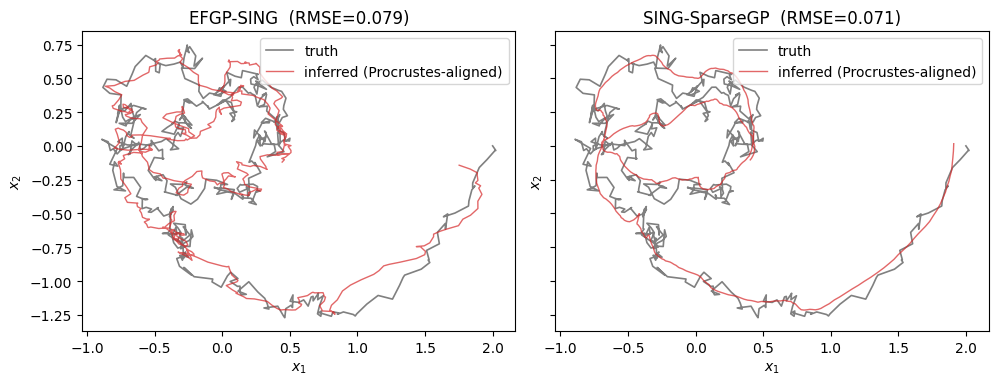

EFGP    latent RMSE (Procrustes-aligned): 0.0787
SparseGP latent RMSE (Procrustes-aligned): 0.0711


In [13]:
def procrustes_align(m_inferred, m_true):
    """Solve for affine (A, b) minimizing || A x_inf + b - x_true ||."""
    Xi = m_inferred; Xt = m_true
    bi = Xi.mean(0); bt = Xt.mean(0)
    A_T, *_ = np.linalg.lstsq(Xi - bi, Xt - bt, rcond=None)
    A = A_T.T
    b = bt - A @ bi
    return A, b, Xi @ A.T + b

m_efgp = np.asarray(mp_efgp['m'][0])
m_sp = np.asarray(mp_sp['m'][0])
A_efgp, b_efgp, m_efgp_align = procrustes_align(m_efgp, xs_np)
A_sp, b_sp, m_sp_align = procrustes_align(m_sp, xs_np)
lat_rmse_efgp = float(np.sqrt(np.mean((m_efgp_align - xs_np) ** 2)))
lat_rmse_sp = float(np.sqrt(np.mean((m_sp_align - xs_np) ** 2)))

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, mt, name, rmse in zip(
        axes, [m_efgp_align, m_sp_align],
        ['EFGP-SING', 'SING-SparseGP'],
        [lat_rmse_efgp, lat_rmse_sp]):
    ax.plot(xs_np[:, 0], xs_np[:, 1], lw=1.2, color='gray', label='truth')
    ax.plot(mt[:, 0], mt[:, 1], lw=1.0, color='C3', alpha=0.7,
            label='inferred (Procrustes-aligned)')
    ax.set_title(f'{name}  (RMSE={rmse:.3f})')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

print(f'EFGP    latent RMSE (Procrustes-aligned): {lat_rmse_efgp:.4f}')
print(f'SparseGP latent RMSE (Procrustes-aligned): {lat_rmse_sp:.4f}')


## 7. Drift recovery on a 12x12 grid (truth basis)

In [8]:
# 12x12 grid spanning the latent cloud bbox (truth coords)
grid_lo = xs_np.min(0) - 0.3; grid_hi = xs_np.max(0) + 0.3
g1 = np.linspace(grid_lo[0], grid_hi[0], 12)
g2 = np.linspace(grid_lo[1], grid_hi[1], 12)
GX, GY = np.meshgrid(g1, g2, indexing='ij')
grid_pts = np.stack([GX.ravel(), GY.ravel()], axis=-1)
f_true_grid = drift_np(grid_pts)
drift_rmse_zero = float(np.sqrt(np.mean(f_true_grid ** 2)))
print(f'zero-drift baseline RMSE: {drift_rmse_zero:.4f}')

# ---- EFGP drift in TRUTH basis ----
# Build adaptive-h grid at the EM-final hypers (same policy as training).
A_inv_efgp = np.linalg.inv(A_efgp)
grid_efgp_basis = (grid_pts - b_efgp) @ A_inv_efgp.T
X_template_e = jnp.linspace(-3., 3., 16)[:, None] * jnp.ones((1, D))
grid_jax_e = jp.spectral_grid_se(ls_efgp_final, var_efgp_final,
                                  X_template_e, eps=1e-2)
ms_eval = jnp.asarray(m_efgp)
Ss_eval = jnp.asarray(np.asarray(mp_efgp['S'][0]))
SSs_eval = jnp.asarray(np.asarray(mp_efgp['SS'][0]))
del_t = t_grid[1:] - t_grid[:-1]
mu_r, _, _ = jpd.compute_mu_r_jax(
    ms_eval, Ss_eval, SSs_eval, del_t, grid_jax_e, jr.PRNGKey(99),
    sigma_drift_sq=sigma_diffusion ** 2, S_marginal=2,
    D_lat=D, D_out=D,
)
Ef_grid_e, _, _ = jpd.drift_moments_jax(
    mu_r, grid_jax_e,
    jnp.asarray(grid_efgp_basis, dtype=jnp.float32),
    D_lat=D, D_out=D)
f_efgp_truth = np.asarray(Ef_grid_e) @ A_efgp.T
drift_rmse_efgp = float(np.sqrt(np.mean(
    (f_efgp_truth - f_true_grid) ** 2)))

# ---- SparseGP drift in TRUTH basis ----
A_inv_sp = np.linalg.inv(A_sp)
grid_sp_basis = (grid_pts - b_sp) @ A_inv_sp.T
gp_post_sp = sparse_drift.update_dynamics_params(
    jr.PRNGKey(0), t_grid, mp_sp, jnp.ones((1, T), dtype=bool),
    sp_drift_params,
    jnp.zeros((1, T, 1)),
    jnp.zeros((D, 1)), sigma_diffusion)
f_sp_inferred = np.asarray(sparse_drift.get_posterior_f_mean(
    gp_post_sp, sp_drift_params, jnp.asarray(grid_sp_basis)))
f_sp_truth = f_sp_inferred @ A_sp.T
drift_rmse_sp = float(np.sqrt(np.mean((f_sp_truth - f_true_grid) ** 2)))

print(f'EFGP    drift RMSE: {drift_rmse_efgp:.4f}  '
      f'(zero baseline {drift_rmse_zero:.4f})')
print(f'SparseGP drift RMSE: {drift_rmse_sp:.4f}  '
      f'(zero baseline {drift_rmse_zero:.4f})')


zero-drift baseline RMSE: 1.2453
EFGP    drift RMSE: 0.4214  (zero baseline 1.2453)
SparseGP drift RMSE: 0.3669  (zero baseline 1.2453)


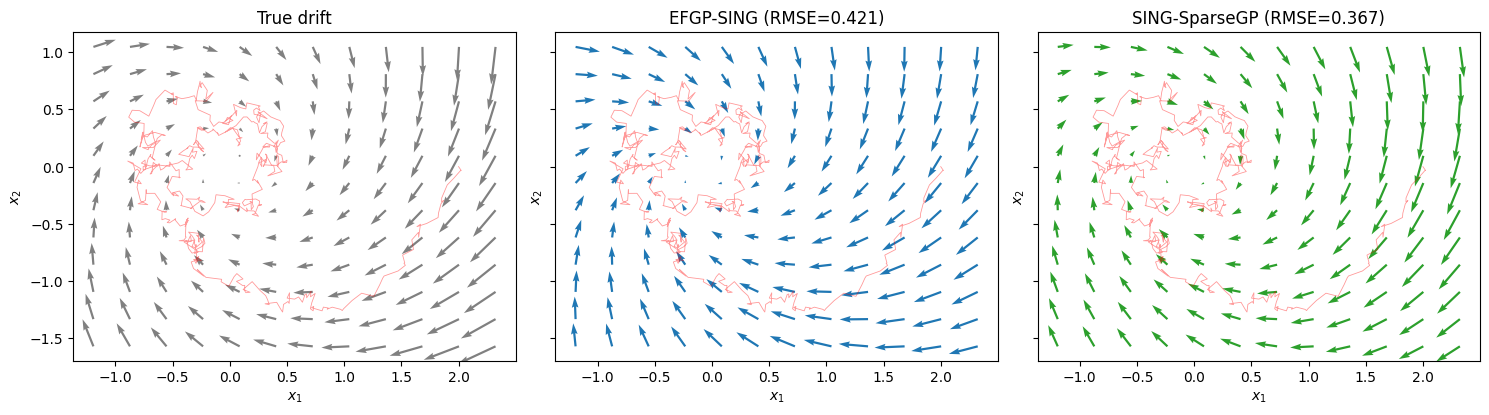

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
panels = [
    ('True drift', f_true_grid, 'gray'),
    (f'EFGP-SING (RMSE={drift_rmse_efgp:.3f})', f_efgp_truth, 'C0'),
    (f'SING-SparseGP (RMSE={drift_rmse_sp:.3f})', f_sp_truth, 'C2'),
]
for ax, (title, F, color) in zip(axes, panels):
    ax.quiver(GX, GY, F[:, 0].reshape(GX.shape), F[:, 1].reshape(GX.shape),
              color=color, scale_units='xy', angles='xy')
    ax.plot(xs_np[:, 0], xs_np[:, 1], lw=0.6, color='red', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()


## 8. Summary table

In [15]:
from IPython.display import Markdown
rows = [
    ('EFGP-SING', t_efgp, lat_rmse_efgp, drift_rmse_efgp,
     ls_efgp_final, var_efgp_final),
    ('SING-SparseGP', t_sp, lat_rmse_sp, drift_rmse_sp,
     ls_sp_final, var_sp_final),
]
header = '| method | wall (s) | latent RMSE | drift RMSE | final ell | final sigma^2 |\n'
header += '|---|---:|---:|---:|---:|---:|\n'
body = ''
for name, wall, lr, dr, ls, var in rows:
    body += f'| {name} | {wall:.1f} | {lr:.4f} | {dr:.4f} | {ls:.3f} | {var:.3f} |\n'
body += f'\n*zero-drift baseline RMSE = {drift_rmse_zero:.4f}*\n'
Markdown(header + body)


| method | wall (s) | latent RMSE | drift RMSE | final ell | final sigma^2 |
|---|---:|---:|---:|---:|---:|
| EFGP-SING | 50.5 | 0.0787 | 0.4214 | 0.966 | 0.510 |
| SING-SparseGP | 62.6 | 0.0711 | 0.3669 | 1.759 | 1.372 |

*zero-drift baseline RMSE = 1.2453*
